# Comparative Analysis of Heart Disease Risk Factors
---
A Data Science Approach for Exploring and Comparing Cardiovascular Risk Indicators

Dataset 1 Link source: https://www.kaggle.com/datasets/vishardmehta/heart-risk-progression-dataset


| Feature | Description |
|---|---|
| **Patient_ID** | Unique identifier for each patient |
| **age** | Age of the patient in years |
| **bmi** | Body Mass Index indicating body fat based on height and weight |
| **systolic_bp** | Systolic blood pressure level |
| **diastolic_bp** | Diastolic blood pressure level |
| **cholesterol_mg_dl** | Total cholesterol level measured in mg/dL |
| **resting_heart_rate** | Resting heart rate in beats per minute |
| **smoking_status** | Smoking category (Never, Former, Current) |
| **daily_steps** | Average number of steps taken per day |
| **stress_level** | Stress level on a scale from 1 to 10 |
| **physical_activity_hours_per_week** | Weekly hours of physical exercise |
| **sleep_hours** | Average hours of sleep per night |
| **family_history_heart_disease** | Indicates whether the patient has a family history of heart disease |
| **diet_quality_score** | Score from 1 to 10 representing diet quality |
| **alcohol_units_per_week** | Weekly alcohol consumption |
| **heart_disease_risk_score** | Calculated cardiovascular risk score (0–100) |
| **risk_category** | Risk classification: Low, Medium, or High |

Dataset 2 Link source: https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid

| Feature | Description |
|---|---|
| **Age** | Age of the patient |
| **Gender** | Biological sex of the patient (Male = 1, Female = 0) |
| **Heart Rate** | Number of heartbeats per minute |
| **Systolic Blood Pressure** | Pressure in the arteries when the heart contracts |
| **Diastolic Blood Pressure** | Pressure in the arteries between heartbeats |
| **Blood Sugar** | Blood glucose level of the patient |
| **Ck-mb** | Cardiac enzyme released during heart muscle damage |
| **Troponin** | Highly specific protein biomarker for heart muscle injury |
| **Result** | Target variable indicating whether the patient experienced a heart attack |

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL.ImageColor import colormap

from scipy.stats import pearsonr, shapiro, alpha, spearmanr
import scipy.stats as stats

In [111]:
cardiovascular_risk_dataset = pd.read_csv('../data/cardiovascular_risk_dataset.csv')
cardiovascular_risk_dataset.columns = cardiovascular_risk_dataset.columns.str.lower()
cardiovascular_risk_dataset

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [112]:
crd = cardiovascular_risk_dataset.copy()

With this step below, we examine how the risk score separates patients into the three different risk categories.

In [113]:
crd[crd['risk_category'] == 'Low']['heart_disease_risk_score'].max()

np.float64(24.9)

Low risk category:
Patients with a heart disease risk score
between 0% and approximately 25%.

In [114]:
crd[crd['risk_category'] == 'Medium']['heart_disease_risk_score'].max()

np.float64(54.9)

**Medium risk category:**
Patients with a heart disease risk score
between 25% and 55%.

**High risk category:**
Patients with a heart disease risk score
above 55%.

### Dataset Hypotheses
---

#### Hypothesis 1 - Age and Heart Disease

- **H0 (Null Hypothesis):** There is no relationship between age and heart disease risk.
- **H1 (Alternative Hypothesis):** Older people are more likely to suffer from heart disease.



#### Hypothesis 2 - BMI and Heart Disease

- **H0 (Null Hypothesis):** BMI has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher BMI are more likely to suffer from heart disease.



#### Hypothesis 3 - Blood Pressure and Heart Disease

- **H0 (Null Hypothesis):** Blood pressure has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher blood pressure are more likely to suffer from heart disease.



#### Hypothesis 4 - Sleep and Stress Level

- **H0 (Null Hypothesis):** Sleep duration has no relationship with stress levels.
- **H1 (Alternative Hypothesis):** People with fewer hours of sleep are more likely to experience higher stress levels.



#### Hypothesis 5 - Stress and Heart Disease

- **H0 (Null Hypothesis):** Stress level has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher stress levels are more likely to suffer from heart disease.



#### Hypothesis 6 - Alcohol Consumption and Heart Disease

- **H0 (Null Hypothesis):** Alcohol consumption has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** Frequent alcohol consumption increases the likelihood of heart disease.

In [115]:
medical_dataset = pd.read_csv('../data/Medicaldataset.csv')
medical_dataset.columns = medical_dataset.columns.str.lower()
medical_dataset

,age,gender,heart rate,systolic blood pressure,diastolic blood pressure,blood sugar,ck-mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [116]:
md = medical_dataset.copy()

#### Hypothesis 7 — Gender and Heart Disease

- **H0 (Null Hypothesis):** Gender has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** Men are more likely to suffer from heart disease.

In [117]:
md['result'] = md['result'].map({
    'positive': 1,
    'negative': 0
})

In [118]:
md.columns = md.columns.str.replace(' ', '_')
md.columns = md.columns.str.replace('-', '_')

In [119]:
md

,age,gender,heart_rate,systolic_blood_pressure,diastolic_blood_pressure,blood_sugar,ck_mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


### Data verification

In [120]:
#Checking the shape of the dataset
crd.shape

(5500, 17)

In [121]:
# Checking entire dataset for null values
crd.isnull().values.any()

np.False_

In [122]:
#Checking the shape of the dataset
md.shape

(1319, 9)

In [123]:
# Checking entire dataset for null values
md.isnull().values.any()

np.False_

### Descriptive Statistics

In [124]:
# Checking the age of the people (observations) in the data
crd.describe()

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


In [125]:
md.describe()

,age,gender,heart_rate,systolic_blood_pressure,diastolic_blood_pressure,blood_sugar,ck_mb,troponin,result
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.614102
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,1.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


From the perspective of age distribution, the selected observations in both datasets appear relatively similar. Some differences can still be observed, but this is generally unavoidable in most real-world datasets.

### Data Analysis

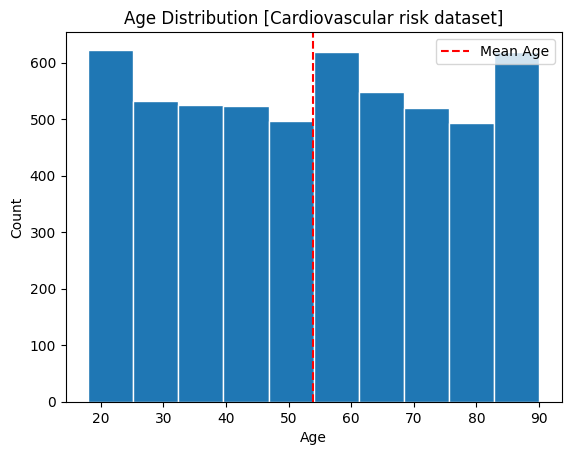

In [126]:
plt.hist(crd['age'], edgecolor='white', bins=10)

mean_age = crd['age'].mean()

plt.axvline(mean_age, color='red', linestyle='--', label='Mean Age')

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution [Cardiovascular risk dataset]')

plt.legend()

plt.show()

The age distribution appears relatively balanced across the dataset, with observations spread throughout all age groups. No extreme concentration in a specific age interval can be observed.

The average age is ~55, indicating that the dataset mainly focuses on middle-aged and older individuals, which is reasonable in the context of cardiovascular risk analysis.

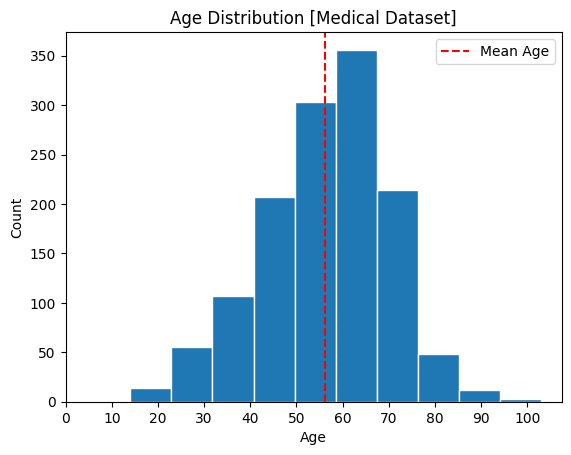

In [127]:
plt.hist(md['age'], edgecolor='white', bins=10)

mean_age = md['age'].mean()

plt.axvline(mean_age, color='red', linestyle='--', label='Mean Age')

plt.xlabel('Age')
plt.ylabel('Count')

plt.xticks(range(0, 101, 10))

plt.title('Age Distribution [Medical Dataset]')

plt.legend()

plt.show()

The age distribution in this dataset appears approximately normal, with most observations concentrated between the ages of 45 and 70.

The average age is around 55, suggesting that the dataset mainly includes middle-aged and older individuals. Very young and very old patients are relatively rare in the dataset.

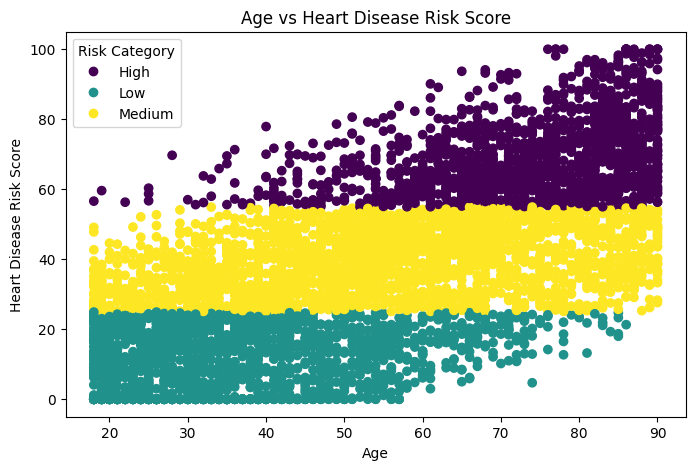

In [128]:
# Scatter plot showing the relationship between age
# and heart disease risk score.

# Each point represents a single patient.

# The colors indicate the patient's risk category
# (Low, Medium, High).

# This visualization helps identify whether
# older patients tend to have higher cardiovascular risk.

categories = crd['risk_category'].astype('category')

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    crd['age'],
    crd['heart_disease_risk_score'],
    c=categories.cat.codes
)

plt.xlabel('Age')
plt.ylabel('Heart Disease Risk Score')
plt.title('Age vs Heart Disease Risk Score')

handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    categories.cat.categories,
    title="Risk Category"
)

plt.show()

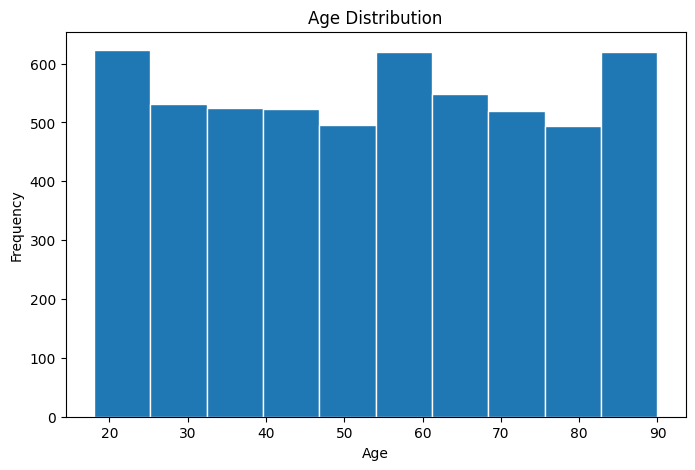

In [129]:
# Age Distribution Visualization
# A histogram was created to examine the distribution of the `age` feature in the dataset.
# Understanding the distribution of the `age` variable is important before performing statistical analysis because many statistical methods, including Pearson correlation, work more reliably when the data does not contain extreme irregularities.
plt.figure(figsize=(8,5))

plt.hist(crd['age'], bins=10, edgecolor='white')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()

The histogram shows a relatively balanced distribution of age values across the dataset.

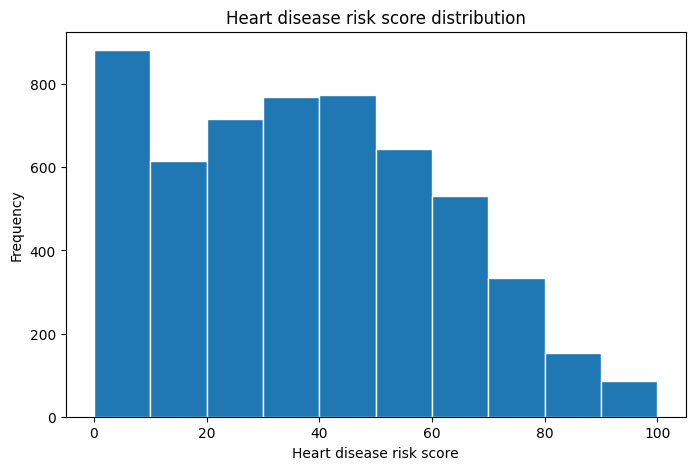

In [130]:
plt.figure(figsize=(8,5))

plt.hist(crd['heart_disease_risk_score'], bins=10, edgecolor='white')

plt.xlabel('Heart disease risk score')
plt.ylabel('Frequency')
plt.title('Heart disease risk score distribution')

plt.show()

The distribution of the heart disease risk score is moderately right-skewed. Lower and medium risk scores appear more frequently, while very high risk scores are less common in the dataset.

#### Hypothesis 1 - Age and Heart Disease

- **H0 (Null Hypothesis):** There is no relationship between age and heart disease risk.
- **H1 (Alternative Hypothesis):** Older people are more likely to suffer from heart disease.

Pearson Correlation Analysis

In this analysis, Pearson correlation was used to examine the relationship between `age` and `heart_disease_risk_score`.

Pearson correlation is appropriate because both variables are numerical and their distributions appear relatively balanced without extreme skewness or abnormal concentration of values.

In [131]:
corr, p_value = pearsonr(
    crd['age'],
    crd['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6942860722556741
P-value: 0.0


The correlation coefficient indicates a strong positive linear relationship between age and heart disease risk score.

This means that, in general, as age increases, the heart disease risk score also tends to increase.

Additionally, the p-value is significantly lower than the standard significance threshold of `0.05`, meaning that the relationship is statistically significant.

Therefore:

- The null hypothesis (`H0`) is rejected.
- The alternative hypothesis (`H1`) is accepted - `Older people are more likely to suffer from heart disease.`

#### Hypothesis 2 - BMI and Heart Disease

- **H0 (Null Hypothesis):** BMI has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher BMI are more likely to suffer from heart disease.

In [132]:
crd['bmi'].describe()

count    5500.000000
mean       28.170818
std         4.189877
min        15.000000
25%        25.200000
50%        28.400000
75%        31.100000
max        40.900000
Name: bmi, dtype: float64

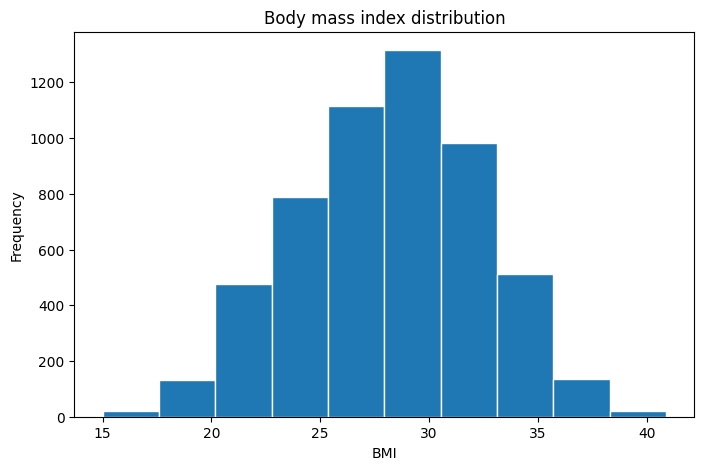

In [133]:
# The first step is to visualize the distribution of the data. After that, we will perform a statistical test.
plt.figure(figsize=(8,5))

plt.hist(crd['bmi'], bins=10, edgecolor='white')

plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Body mass index distribution')

plt.show()

At first glance, the distribution appears to be Gaussian (normal), but to confirm this, we will use the statistical Shapiro–Wilk test.

Source link: https://www.youtube.com/watch?v=eh9eYLBecWk

Source link: https://www.youtube.com/watch?v=e0lum-6vuw4

$$
\Large
W =
\frac{
\left(
\sum_{i=1}^{n} a_i x_{(i)}
\right)^2
}{
\sum_{i=1}^{n} (x_i - \bar{x})^2
}
$$

$$
\Large
\sum_{i=1}^{n} a_i x_{(i)}
\quad
\large
\text{estimates the slope of the Q-Q plot line in the Shapiro-Wilk test}
$$

$$
\large
\text{$a_i$ coefficients incorporate the normal order statistics,}
$$

$$
\large
\text{the variance-covariance structure of the ordered sample values,}
$$

$$
\large
\text{and a normalization factor related to the scale of the data.}
$$

Null vs Alternative hypothesis:

- H0 - the data is normally distributed
- H1 - the data is not normally distributed

Reject the null hypothesis if the `p` value is less then alpha

Typically set alpha to 0.05

In [134]:
alpha_value = 0.05
stat, shapiro_p_value = shapiro(crd['bmi'])

X:\venvs\ds_retake_exam_2026\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5500.
  res = hypotest_fun_out(*samples, **kwds)


In [135]:
stat

np.float64(0.9961791415182911)

In [136]:
shapiro_p_value

np.float64(9.2306598065932e-11)

Although the Shapiro-Wilk test rejects the null hypothesis due to the extremely small p-value, the W statistic (0.996) is very close to 1, indicating that the distribution is visually close to normal. The large sample size (N = 5500) makes the test highly sensitive to small deviations from normality.

We will additionally examine the distribution using a Q-Q plot to visually compare the data against a theoretical normal distribution.

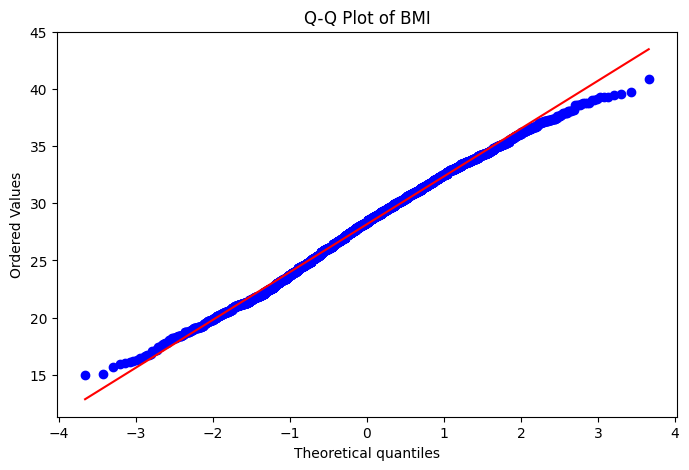

In [137]:
plt.figure(figsize=(8,5))

stats.probplot(crd['bmi'], dist="norm", plot=plt)

plt.title('Q-Q Plot of BMI')

plt.show()

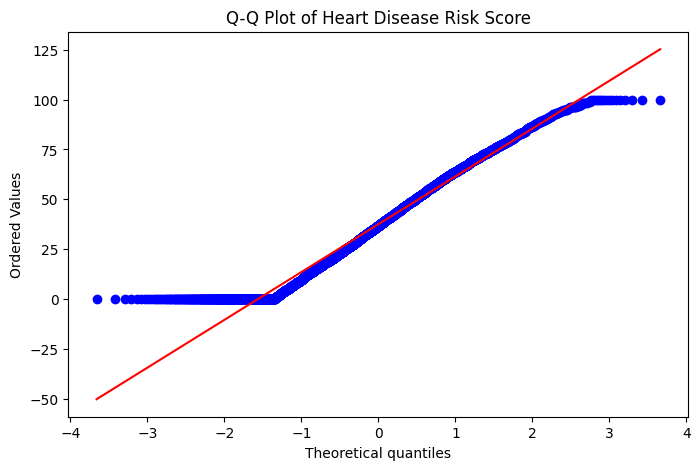

In [138]:
plt.figure(figsize=(8,5))

stats.probplot(crd['heart_disease_risk_score'], dist="norm", plot=plt)

plt.title('Q-Q Plot of Heart Disease Risk Score')

plt.show()

The Q-Q plot shows that most data points closely follow the reference line, indicating that the BMI feature is approximately normally distributed.

Based on the conducted normality analysis, the BMI feature appears approximately normally distributed, while the heart disease risk score shows noticeable deviations from a Gaussian distribution according to the Q-Q plot. Therefore, Spearman correlation will be used instead of Pearson correlation. Spearman correlation is a non-parametric statistical method that does not require the variables to follow a normal distribution and is appropriate for measuring monotonic relationships between variables.

The conclusion we can draw at this stage is that even if the data appears to be approximately normally distributed, additional statistical tests are necessary to verify this assumption. Initially, we selected Pearson correlation for testing the first hypothesis, but after further analysis, we determined that Spearman correlation is a more appropriate approach.

Therefore, the initial approach used for testing the first hypothesis may not have been entirely appropriate from the perspective of the selected correlation method.

In [139]:
corr, p_value = spearmanr(
    crd['bmi'],
    crd['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.70701378006921
P-value: 0.0


The Spearman correlation analysis revealed a strong positive relationship between BMI and heart disease risk score, with a correlation coefficient of approximately 0.707. This indicates that higher BMI values tend to be associated with higher cardiovascular risk scores.

In addition, the obtained p-value is effectively 0.0, which is significantly lower than the selected significance level (а = 0.05). Therefore, the relationship is statistically significant, and the null hypothesis can be rejected.

These results suggest that BMI is strongly associated with an increased risk of heart disease in the analyzed dataset.

#### Hypothesis 3 - Blood Pressure and Heart Disease

- **H0 (Null Hypothesis):** Blood pressure has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher blood pressure are more likely to suffer from heart disease.

In [140]:
crd

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [141]:
crd['systolic_bp'].describe()

count    5500.000000
mean      147.248182
std        13.222701
min       108.000000
25%       138.000000
50%       147.000000
75%       156.000000
max       192.000000
Name: systolic_bp, dtype: float64

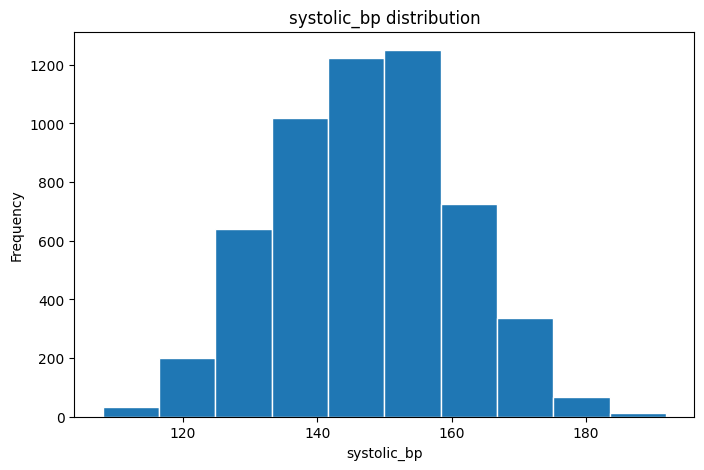

In [142]:
# This histogram visualizes the distribution
# of systolic blood pressure values in the dataset.
plt.figure(figsize=(8,5))

plt.hist(crd['systolic_bp'], bins=10, edgecolor='white')

plt.xlabel('systolic_bp')
plt.ylabel('Frequency')
plt.title('systolic_bp distribution')

plt.show()

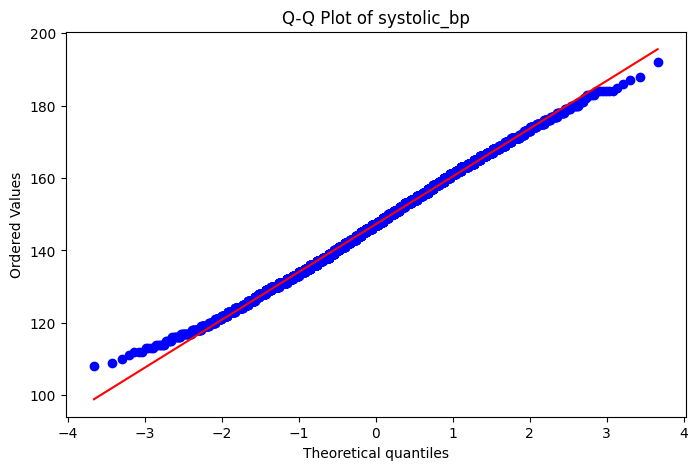

In [143]:
# The Q-Q plot compares the systolic blood pressure
# distribution against a theoretical normal distribution.
plt.figure(figsize=(8,5))

stats.probplot(crd['systolic_bp'], dist="norm", plot=plt)

plt.title('Q-Q Plot of systolic_bp')

plt.show()

In [144]:
# Since the heart disease risk score
# is not normally distributed according
# to the Q-Q plot analysis, Spearman
# correlation is used instead of Pearson correlation.
corr, p_value = spearmanr(
    crd['systolic_bp'],
    crd['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9047149025687259
P-value: 0.0


The Spearman correlation analysis revealed a very strong positive relationship between systolic blood pressure and heart disease risk score, with a correlation coefficient of approximately 0.905. This indicates that higher systolic blood pressure values are strongly associated with increased cardiovascular risk.

In addition, the obtained p-value is effectively 0.0, which is significantly lower than the selected significance level (а = 0.05). Therefore, the relationship is statistically significant, and the null hypothesis can be rejected.

These results suggest that systolic blood pressure is a strong predictor of heart disease risk in the analyzed dataset.

---

In the next step, we will connect some of the indicators in order to examine possible cause-and-effect relationships. We will investigate whether shorter sleep duration leads to increased stress levels and, consequently, whether higher stress levels contribute to a higher heart disease risk factor.

#### Hypothesis 4 - Sleep and Stress Level

- **H0 (Null Hypothesis):** Sleep duration has no relationship with stress levels.
- **H1 (Alternative Hypothesis):** People with fewer hours of sleep are more likely to experience higher stress levels.

#### Hypothesis 5 - Stress and Heart Disease

- **H0 (Null Hypothesis):** Stress level has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher stress levels are more likely to suffer from heart disease.

In [145]:
crd

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [146]:
crd['sleep_hours'].describe()

count    5500.000000
mean        6.869364
std         1.091263
min         4.000000
25%         6.200000
50%         6.900000
75%         7.600000
max        10.000000
Name: sleep_hours, dtype: float64

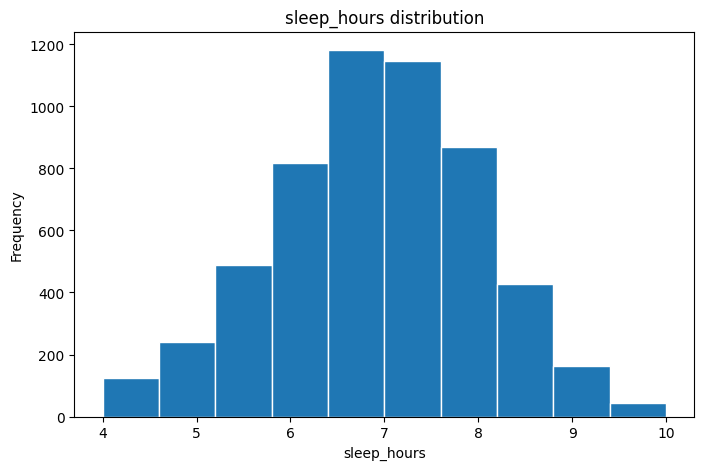

In [147]:
# Display the distribution of sleep hours
plt.figure(figsize=(8,5))

plt.hist(crd['sleep_hours'], bins=10, edgecolor='white')

plt.xlabel('sleep_hours')
plt.ylabel('Frequency')
plt.title('sleep_hours distribution')

plt.show()

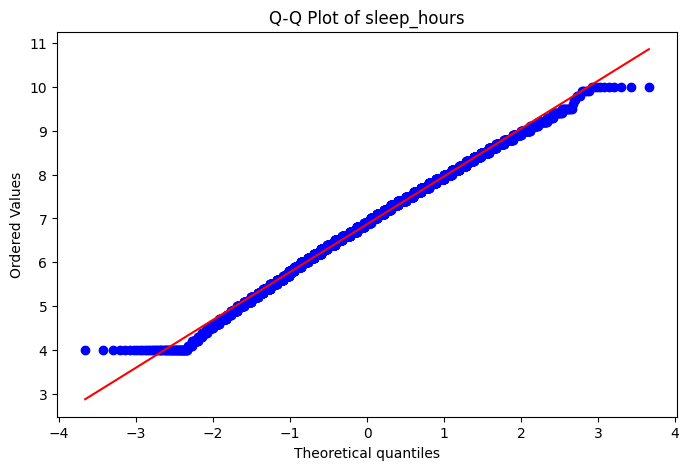

In [148]:
# Create a Q-Q plot to evaluate whether
# sleep_hours follows a normal distribution.

# If the points closely follow the red line,
# the data can be considered approximately normal.
plt.figure(figsize=(8,5))

stats.probplot(crd['sleep_hours'], dist="norm", plot=plt)

plt.title('Q-Q Plot of sleep_hours')

plt.show()

The points generally follow the reference line, indicating that `sleep_hours` is approximately normally distributed.

However, slight deviations are visible at the lower and upper ends of the distribution, suggesting minor departures from perfect normality.

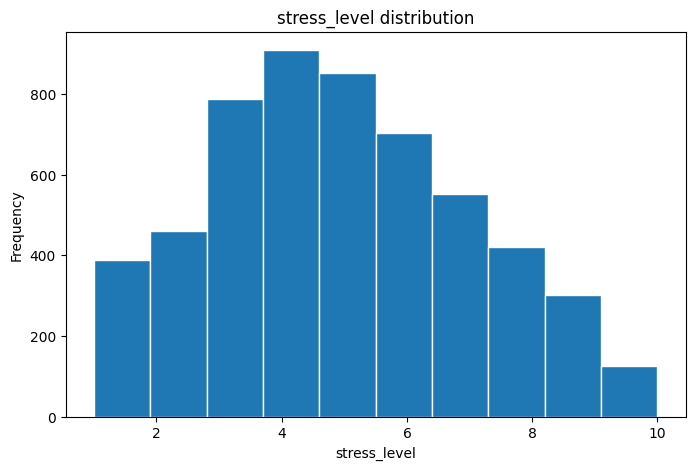

In [149]:
# Display the distribution of stress levels
# among patients in the dataset.
plt.figure(figsize=(8,5))

plt.hist(crd['stress_level'], bins=10, edgecolor='white')

plt.xlabel('stress_level')
plt.ylabel('Frequency')
plt.title('stress_level distribution')

plt.show()

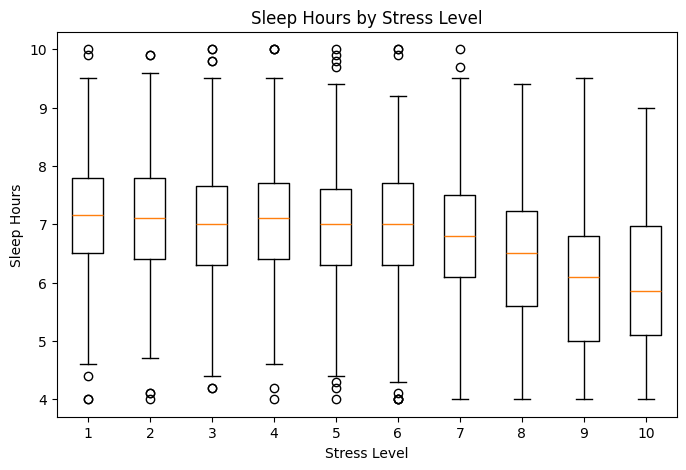

In [150]:
# Create a boxplot to compare sleep duration
# across different stress level categories.

# Each box represents the distribution
# of sleep hours for a specific stress level (1–10).

# The visualization helps identify whether
# people with higher stress levels tend to sleep less.
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        crd[crd['stress_level'] == i]['sleep_hours']
        for i in sorted(crd['stress_level'].unique())
    ],
    tick_labels=sorted(crd['stress_level'].unique())
)

plt.xlabel('Stress Level')
plt.ylabel('Sleep Hours')
plt.title('Sleep Hours by Stress Level')

plt.show()

The boxplot suggests a negative relationship between sleep duration and stress level.

Patients with lower stress levels (1–4) generally sleep around 7 hours on average, while patients with higher stress levels (8–10) tend to have lower median sleep duration.

The median sleep hours gradually decrease as stress levels increase, indicating that shorter sleep may be associated with higher stress.


In [151]:
# Calculate the Spearman correlation between
# sleep duration and stress level.

# Spearman correlation is used because
# stress_level is an ordinal variable (1–10)
# and the relationship may not be perfectly linear.

# The test measures whether lower sleep duration
# is associated with higher stress levels.

# The p-value is used to determine
# whether the relationship is statistically significant.
corr, p_value = spearmanr(
    crd['sleep_hours'],
    crd['stress_level']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.18970910359219803
P-value: 9.825514960481052e-46


The Spearman correlation coefficient shows a weak negative relationship between sleep duration and stress level (`-0.19`).

This suggests that people who sleep fewer hours tend to experience slightly higher stress levels.

The p-value is extremely small (`p < 0.05`), indicating that the relationship is statistically significant.

Therefore, we reject the null hypothesis and accept that reduced sleep duration is associated with increased stress levels.

In [152]:
corr, p_value = spearmanr(
    crd['stress_level'],
    crd['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.37150969906437453
P-value: 1.3927786586244065e-179


### Conclusions

- The Spearman correlation coefficient is approximately 0.37, which indicates a moderate positive relationship between stress level and heart disease risk score.

- This suggests that patients with higher stress levels tend to have a higher cardiovascular risk.

- The p-value is extremely small (1.39e-179), meaning the relationship is statistically significant and very unlikely to have occurred by chance.

- The results support the hypothesis that stress may contribute to increased heart disease risk.

- Although the relationship is statistically significant, correlation does not necessarily imply causation, meaning stress may be associated with other contributing health or lifestyle factors.

In [153]:
corr, p_value = spearmanr(
    crd['sleep_hours'],
    crd['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.09140556344169595
P-value: 1.1097523569605678e-11


### Conclusions

- The Spearman correlation coefficient is approximately -0.09, which indicates a very weak negative relationship between sleep duration and heart disease risk score.

- This suggests that patients who sleep more hours tend to have a slightly lower cardiovascular risk, but the relationship is extremely weak.

- The p-value is very small (`1.10e-11`), which means the observed relationship is statistically significant and unlikely to be caused by random chance.

- Although the correlation is statistically significant, the effect size is minimal, meaning that sleep duration alone is not a strong predictor of heart disease risk in this dataset.

- Other medical and lifestyle factors are likely to have a much greater influence on cardiovascular risk.

**At this stage, we examined several of the initial hypotheses formulated for the first dataset. Next, we will explore the remaining features of the dataset in order to gain a better understanding of the individuals included in the data.**

In [154]:
crd['daily_steps'].describe()

count     5500.000000
mean      5902.929455
std       3041.084590
min        500.000000
25%       3428.000000
50%       5460.000000
75%       7772.000000
max      16793.000000
Name: daily_steps, dtype: float64

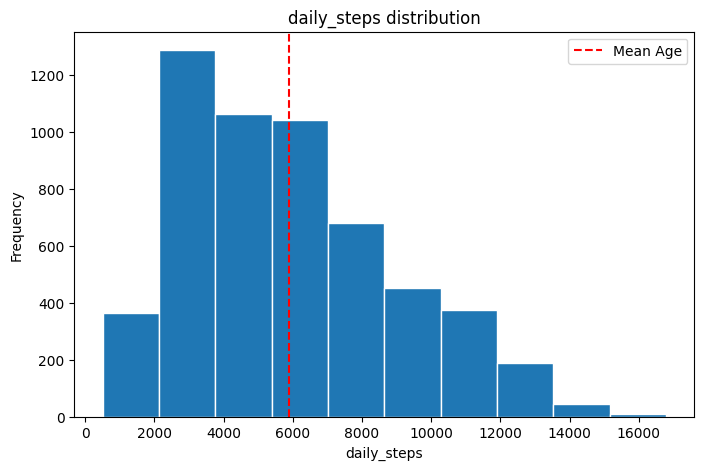

In [155]:
plt.figure(figsize=(8,5))

mean_value = crd['daily_steps'].mean()

plt.hist(crd['daily_steps'], bins=10, edgecolor='white')
plt.axvline(mean_value, color='red', linestyle='--', label='Mean Age')


plt.xlabel('daily_steps')
plt.ylabel('Frequency')
plt.legend()
plt.title('daily_steps distribution')

plt.show()

## Creating Physical Activity Groups

To better analyze the relationship between daily physical activity and cardiovascular risk, the participants were divided into three separate groups based on their average daily step count.

The groups were defined as:

- Low Activity - up to 5,000 steps per day
- Medium Activity - between 5,001 and 10,000 steps per day
- High Activity → above 10,000 steps per day

This categorization helps simplify the analysis and allows us to compare cardiovascular risk levels between people with different levels of physical activity.

In [156]:
low_activity = crd[crd['daily_steps'] < 5000]
medium_activity = crd[(crd['daily_steps'] >= 5001) & (crd['daily_steps'] <= 10000)]
high_activity = crd[crd['daily_steps'] > 10000]

In [157]:
low_activity['risk_category'].value_counts()

risk_category
Medium    1085
High       986
Low        418
Name: count, dtype: int64

In [158]:
medium_activity['risk_category'].value_counts()

risk_category
Low       971
Medium    947
High      422
Name: count, dtype: int64

In [159]:
high_activity['risk_category'].value_counts()

risk_category
Low       449
Medium    212
High       10
Name: count, dtype: int64

Immediately after observing the numbers, we can already make some initial conclusions.

A very small number of people in the highly active group have a high risk of heart disease. However, this is also the smallest group among the three activity groups.

We will further examine the individuals who maintain a high level of physical activity despite still having a high cardiovascular risk. At this stage, they represent an important point of interest for the analysis.

One possible assumption is that these individuals may have hereditary conditions or could belong to an older age group.

In [160]:
high_activity_high_risk =  high_activity[high_activity['risk_category'] == 'High']
high_activity_high_risk

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
343,344,67,30.4,164,107,249,76,Current,10859,5,3.9,6.0,No,4,6.1,59.5,High
600,601,65,28.5,162,113,246,73,Current,12740,5,6.6,7.5,Yes,7,0.5,59.7,High
786,787,88,26.4,160,99,262,71,Never,10828,3,3.9,7.7,Yes,8,1.1,62.9,High
1359,1360,85,29.8,155,95,251,68,Never,11932,7,5.1,5.1,Yes,8,1.0,58.7,High
1783,1784,86,26.9,157,103,255,79,Never,13727,4,1.9,7.2,No,7,2.6,55.4,High
2906,2907,84,27.6,159,104,269,62,Never,12117,3,7.9,8.1,Yes,7,0.1,56.3,High
3243,3244,70,32.3,148,97,267,79,Never,10906,4,1.2,7.4,No,3,3.1,56.6,High
3762,3763,90,28.1,151,104,259,72,Never,10753,1,2.4,6.4,Yes,7,0.0,56.4,High
3895,3896,88,27.6,152,99,254,67,Never,12379,1,3.9,8.6,Yes,8,0.3,55.8,High
4054,4055,85,25.7,154,106,252,75,Current,13784,2,3.7,7.5,Yes,8,0.2,70.3,High


In [161]:
high_activity_high_risk['family_history_heart_disease'].value_counts()

family_history_heart_disease
Yes    7
No     3
Name: count, dtype: int64

7 of 10 (or 70%) has family history heart disease

In [162]:
high_activity_high_risk['age'].value_counts()

age
88    2
85    2
67    1
65    1
86    1
84    1
70    1
90    1
Name: count, dtype: int64

The results show that most individuals in the high activity and high cardiovascular risk group are elderly people, mainly between 65 and 90 years old.

In the group of highly active individuals, advanced age may be the strongest contributing factor, along with family history related to cardiovascular diseases. The data also shows that these individuals have high systolic blood pressure, which most likely contributes to their classification within the high-risk group.

**The next step will be to compare the three medium groups in order to identify characteristics that may be specific to each of them.**

In [163]:
low_activity = crd[crd['daily_steps'] < 5000]
medium_activity = crd[(crd['daily_steps'] >= 5001) & (crd['daily_steps'] <= 10000)]
high_activity = crd[crd['daily_steps'] > 10000]

In [164]:
la_rc_m = low_activity[low_activity['risk_category'] == 'Medium']
ma_rc_m = medium_activity[medium_activity['risk_category'] == 'Medium']
ha_rc_m = high_activity[high_activity['risk_category'] == 'Medium']

First, we will examine the age distribution of individuals across the three groups. These are people with low, moderate, and high physical activity levels who fall into the medium cardiovascular risk category.

In [165]:
la_rc_m['age'].describe()

count    1085.000000
mean       47.659908
std        16.112597
min        18.000000
25%        35.000000
50%        47.000000
75%        59.000000
max        89.000000
Name: age, dtype: float64

The average age of individuals with low physical activity who fall into the medium cardiovascular risk group is 47 years.

In [166]:
ma_rc_m['age'].describe()

count    947.000000
mean      59.926082
std       17.134551
min       18.000000
25%       48.000000
50%       60.000000
75%       73.000000
max       90.000000
Name: age, dtype: float64

The average age of individuals with medium physical activity who fall into the medium cardiovascular risk group is 59 years.

In [167]:
ha_rc_m['age'].describe()

count    212.000000
mean      76.146226
std       10.523831
min       34.000000
25%       70.000000
50%       78.000000
75%       85.000000
max       90.000000
Name: age, dtype: float64

The average age of individuals with high physical activity who fall into the medium cardiovascular risk group is 76 years.

The conclusion that can be drawn solely from the information currently being analyzed - specifically age, without considering the other contributing factors - is the following:

If a person maintains a low level of physical activity, they may be more likely to fall into the medium cardiovascular risk group around the age of 47.

This interpretation model should also be applied to the remaining groups in the analysis.

In an ideal scenario, the average age should increase while the risk of cardiovascular diseases decreases.

**Now, we will examine the family history of the individuals included in these three groups. The groups represent people with low, moderate, and high physical activity levels who fall into the medium cardiovascular risk category.**

In [168]:
la_rc_m['family_history_heart_disease'].value_counts()

family_history_heart_disease
No     834
Yes    251
Name: count, dtype: int64

In [169]:
ma_rc_m['family_history_heart_disease'].value_counts()

family_history_heart_disease
No     703
Yes    244
Name: count, dtype: int64

In [170]:
ha_rc_m['family_history_heart_disease'].value_counts()

family_history_heart_disease
No     144
Yes     68
Name: count, dtype: int64

In [171]:
round(((834 + 703 + 144) / (834 + 251 + 703 + 244 + 144 + 68)) * 100, 2)

74.91

Approximately 75% of the observations do not have a family history of heart disease.

This suggests that family history of heart disease may not be a major contributing factor for individuals within this group. Assuming that 25% represents a relatively small proportion of people who fall into the medium cardiovascular risk category and also have a family history of heart disease, its overall influence appears to be limited in this particular segment of the dataset.

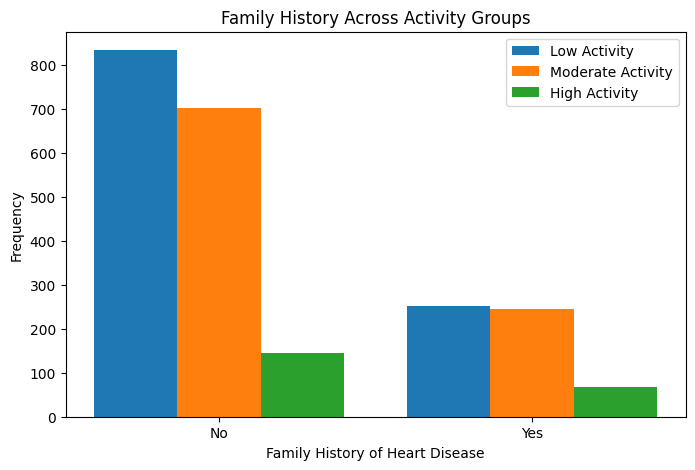

In [172]:
# Plot histograms for the three activity groups.
# Each histogram shows how many individuals
# have or do not have a family history of heart disease.
plt.figure(figsize=(8,5))

plt.hist(
    [
        la_rc_m['family_history_heart_disease'],
        ma_rc_m['family_history_heart_disease'],
        ha_rc_m['family_history_heart_disease']
    ],
    bins=np.arange(-0.5, 2, 1),
    label=['Low Activity', 'Moderate Activity', 'High Activity'],
    rwidth=0.8
)

plt.xticks([0, 1], ['No', 'Yes'])

plt.xlabel('Family History of Heart Disease')
plt.ylabel('Frequency')
plt.title('Family History Across Activity Groups')

plt.legend()

plt.show()

Ultimately, we can observe that most individuals who fall into the medium cardiovascular risk group do not have a family history of heart disease.

In [173]:
la_rc_m = low_activity[low_activity['risk_category'] == 'Medium']
ma_rc_m = medium_activity[medium_activity['risk_category'] == 'Medium']
ha_rc_m = high_activity[high_activity['risk_category'] == 'Medium']

Finally, for this group, we will examine cholesterol levels and whether they have an influence on cardiovascular risk, since this indicator can easily increase due to low physical activity, unhealthy eating habits, and other lifestyle-related factors.

cholesterol_mg_dl - The feature represents the total cholesterol level in a person's blood.

General cholesterol categories:

- Below 200 mg/dL - Normal
- 200–239 mg/dL - Borderline High
- Above 240 mg/dL - High Cholesterol

In [174]:
la_rc_m['cholesterol_mg_dl'].describe()

count    1085.000000
mean      244.504147
std        17.476585
min       184.000000
25%       233.000000
50%       244.000000
75%       257.000000
max       290.000000
Name: cholesterol_mg_dl, dtype: float64

In [175]:
ma_rc_m['cholesterol_mg_dl'].describe()

count    947.000000
mean     241.800422
std       16.198403
min      189.000000
25%      231.000000
50%      241.000000
75%      254.000000
max      284.000000
Name: cholesterol_mg_dl, dtype: float64

In [176]:
ha_rc_m['cholesterol_mg_dl'].describe()

count    212.000000
mean     240.146226
std       13.956341
min      207.000000
25%      231.000000
50%      241.000000
75%      250.000000
max      290.000000
Name: cholesterol_mg_dl, dtype: float64

Based on the observed results, the conclusion that can be drawn from the available data is that, among individuals who fall into the medium cardiovascular risk group and have different levels of physical activity, physical activity does not appear to significantly influence cholesterol levels.

In [183]:
# Observations in risk category `Low` and their mean cholesterol level
crd[crd['risk_category'] == 'Low']['cholesterol_mg_dl'].describe()

count    1838.000000
mean      212.103917
std        18.791338
min       147.000000
25%       199.000000
50%       213.000000
75%       226.000000
max       268.000000
Name: cholesterol_mg_dl, dtype: float64

In [188]:
low_risk = crd[crd['risk_category'] == 'Low']

corr, p_value = spearmanr(
    low_risk['cholesterol_mg_dl'],
    low_risk['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6920963637611884
P-value: 3.0800570872909877e-262


Low Risk Category

The Spearman correlation coefficient shows a strong positive relationship between cholesterol levels and heart disease risk score within the low-risk group (corr ~ 0.69). The extremely small p-value indicates that this relationship is statistically significant and unlikely to be caused by random variation. This suggests that even among individuals classified as low risk, higher cholesterol levels are still associated with increased cardiovascular risk scores.

In [180]:
# Observations in risk category `Medium` and their mean cholesterol level
crd[crd['risk_category'] == 'Medium']['cholesterol_mg_dl'].describe()

count    2244.000000
mean      242.951426
std        16.705251
min       184.000000
25%       232.000000
50%       243.000000
75%       255.000000
max       290.000000
Name: cholesterol_mg_dl, dtype: float64

In [190]:
mid_risk = crd[crd['risk_category'] == 'Medium']

corr, p_value = spearmanr(
    mid_risk['cholesterol_mg_dl'],
    mid_risk['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.5078687392030811
P-value: 1.94330563298997e-147


Medium Risk Category

The results show a moderate positive correlation between cholesterol levels and heart disease risk score in the medium-risk group (corr ~ 0.51). The p-value is extremely small, confirming that the relationship is statistically significant. This indicates that cholesterol remains an important factor influencing cardiovascular risk among individuals in the medium-risk category.

In [178]:
# Observations in risk category `High` and their mean cholesterol level
crd[crd['risk_category'] == 'High']['cholesterol_mg_dl'].describe()

count    1418.000000
mean      270.263047
std        18.134191
min       211.000000
25%       258.000000
50%       271.000000
75%       283.000000
max       331.000000
Name: cholesterol_mg_dl, dtype: float64

In [191]:
high_risk = crd[crd['risk_category'] == 'High']

corr, p_value = spearmanr(
    high_risk['cholesterol_mg_dl'],
    high_risk['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.4460304785571686
P-value: 2.9469432618706096e-70


High Risk Category

The high-risk group also demonstrates a moderate positive correlation between cholesterol levels and heart disease risk score (corr ≈ 0.45). Although the correlation is weaker compared to the low-risk group, the very small p-value confirms that the relationship is statistically significant. This suggests that elevated cholesterol levels continue to be associated with higher cardiovascular risk even among already high-risk individuals.